In [ ]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

directory = './for_keep'

all_dfs = []
for root, dirs, files in os.walk(directory):
    for file in files:
        if file == 'test_metrics.csv':
            # add a column for the run name and parent directory and make index continuous
            df = pd.read_csv(os.path.join(root, file))
            df['parent'] = os.path.basename(os.path.dirname(root))
            df['run'] = os.path.basename(root)
            df.index = range(len(df))            

            all_dfs.append(df)

df = pd.concat(all_dfs)
df = df[df.checkpoint != 'model-final']

wrn_lc_df = df[df['parent'] == 'wrn_lc']
wrn_random_df = df[df['parent'] == 'wrn_random']

def get_stats(df):
    metrics = ['test_cls_loss', 'test_cls_acc', 'test_cls_ece']
    stats_df = df.groupby(['parent', 'checkpoint'])[metrics].agg(['mean', 'std']).round(4)

    # Flatten the multi-level column names
    stats_df.columns = [f"{col[0]}_{col[1]}" for col in stats_df.columns]

    # Reset index to make parent and checkpoint regular columns
    stats_df = stats_df.reset_index()

    # Sort by parent and checkpoint number
    stats_df['checkpoint_num'] = stats_df['checkpoint'].str.extract(r'(\d+)').astype(int)
    stats_df = stats_df.sort_values(['parent', 'checkpoint_num'])
    stats_df = stats_df.drop('checkpoint_num', axis=1)
    
    return stats_df

wrn_lc_stats_df = get_stats(wrn_lc_df)
wrn_random_stats_df = get_stats(wrn_random_df)

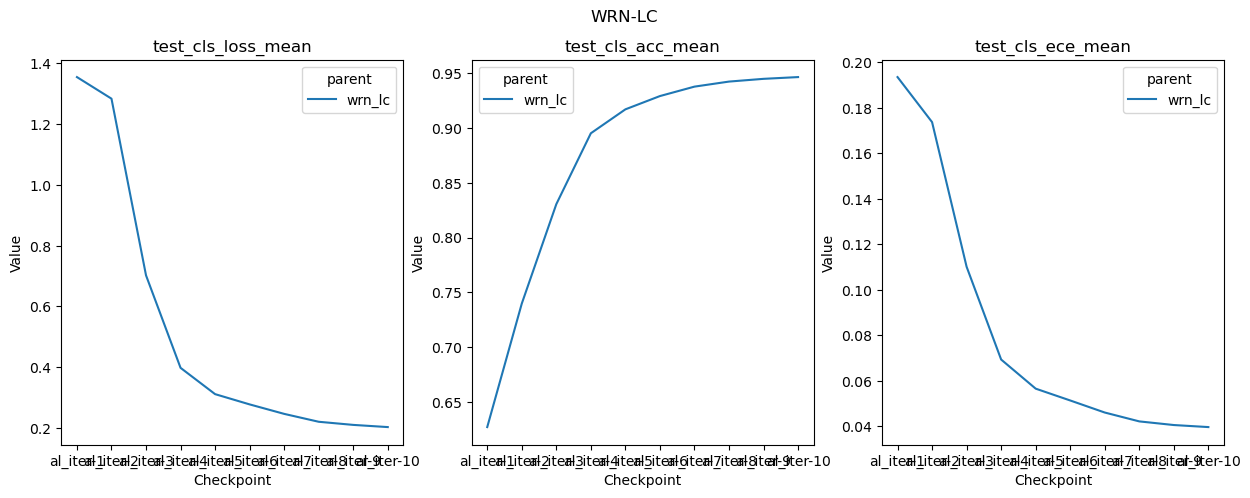

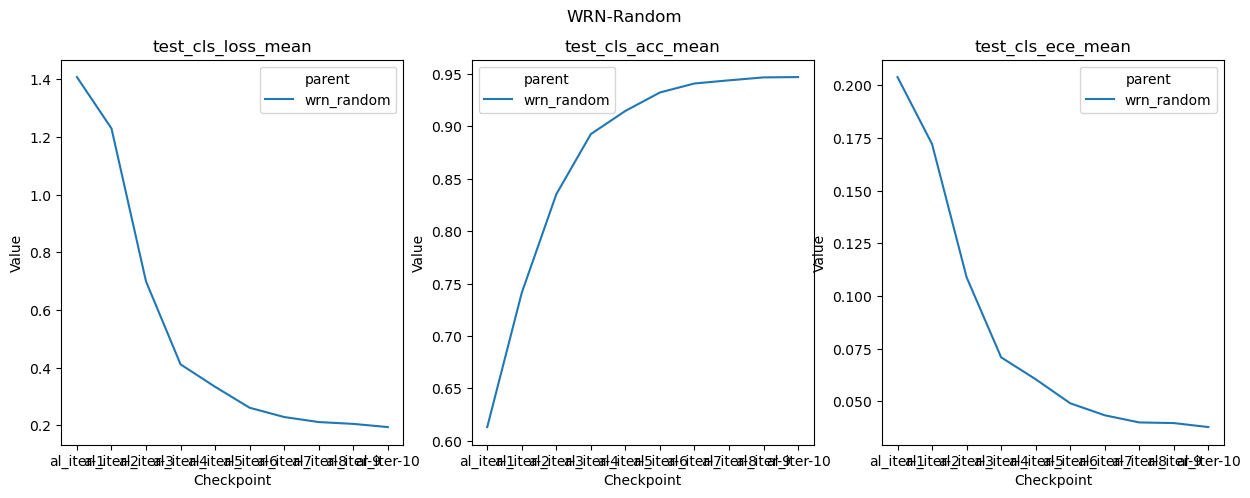

In [58]:

def plot_stats(stats_df, title):
    metrics = ['test_cls_loss_mean', 'test_cls_acc_mean', 'test_cls_ece_mean']
    stats_df = stats_df.set_index('checkpoint')
    stats_df = stats_df.reset_index()  # Ensure 'parent' is not set as index
    stats_df = stats_df[['checkpoint', 'parent'] + metrics]

    # Plot the results
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    for i, metric in enumerate(metrics):
        sns.lineplot(data=stats_df, x='checkpoint', y=metric, hue='parent', ax=ax[i])
        ax[i].set_title(metric)
        ax[i].set_xlabel('Checkpoint')
        ax[i].set_ylabel('Value')
    fig.suptitle(title)
    plt.show()

plot_stats(wrn_lc_stats_df, 'WRN-LC')
plot_stats(wrn_random_stats_df, 'WRN-Random')